## Deep Learning

### Chapter 5: Neural Network for Classification and Regression

Deep Learning can be used to solve more complex classification and regression tasks, where traditional methods might struggle with the nuances of an actual email or a review.

**Binary Classification**

Binary classification is a supervised learning task where the goal is to classify data points into one of two categories. For example, determining if an email is spam or not spam, or if a customer will churn or not churn.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

# Load the top 10,000 most frequent words
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print("Train Size:", x_train.shape)
print("Test Size:", x_test.shape)
print("First samples:", len(x_train[0]), "; Label:", y_train[0])

Train Size: (25000,)
Test Size: (25000,)
First samples: 218 ; Label: 1


The `vectorize_sequences` function, which applies **Multi-Hot Encoding** to the dataset.

Multi-Hot Encoding is a technique used to represent categorical data. In this context, it converts each movie review (a sequence of word indices) into a vector where each element corresponds to a word in the vocabulary.

- If a word is present in the review, its corresponding element in the vector is set to 1.0; otherwise, it's 0. This creates a binary vector representation of the text data.

The function is then applied to both the training and testing sets, and the shapes of the vectorized datasets are printed.

In [3]:
import numpy as np

# Apply Multi-Hot Encoding
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

# Apply to the dataset
x_train = vectorize_sequences(x_train, 10000)
x_test = vectorize_sequences(x_test, 10000)

y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_train).astype('float32')

# Final shape
print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)

Shape x_train: (25000, 10000)
Shape x_test : (25000, 10000)


In [4]:
# Create Validation Set
x_val = x_train[:8000]
partial_x_train = x_train[8000:]

y_val = y_train[:8000]
partial_y_train = y_train[8000:]

print("Shape x_val:", x_val.shape)
print("Shape partial_x_train:", partial_x_train.shape)
print("Shape y_val:", y_val.shape)
print("Shape partial_y_train:", partial_y_train.shape)

Shape x_val: (8000, 10000)
Shape partial_x_train: (17000, 10000)
Shape y_val: (8000,)
Shape partial_y_train: (17000,)


In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# Training the model
hidden_layer1 = layers.Dense(16, activation='relu')
hidden_layer2 = layers.Dense(16, activation='relu')
output_layer = layers.Dense(1, activation='sigmoid')

imdb_model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])

# Compile
imdb_model.compile(optimizer='rmsprop',
                   loss='binary_crossentropy', metrics=['accuracy'])


# Fit the model
history_imdb = imdb_model.fit(partial_x_train, partial_y_train,
                              epochs=20, batch_size=256,
                              validation_data=(x_val, y_val),
                              verbose=1)

# Save it, useful for visualization
history = history_imdb.history

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8244 - loss: 0.4638 - val_accuracy: 0.8725 - val_loss: 0.3372
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9081 - loss: 0.2569 - val_accuracy: 0.8925 - val_loss: 0.2762
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9302 - loss: 0.1929 - val_accuracy: 0.8914 - val_loss: 0.2778
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9446 - loss: 0.1553 - val_accuracy: 0.8889 - val_loss: 0.2969
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9554 - loss: 0.1275 - val_accuracy: 0.8855 - val_loss: 0.3081
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9638 - loss: 0.1069 - val_accuracy: 0.8838 - val_loss: 0.3321
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9706 - loss: 0.0884 - val_accuracy: 0.8834 - val_loss: 0.3591
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9765 - loss: 0.0732 - val_accuracy: 0.8831 - v

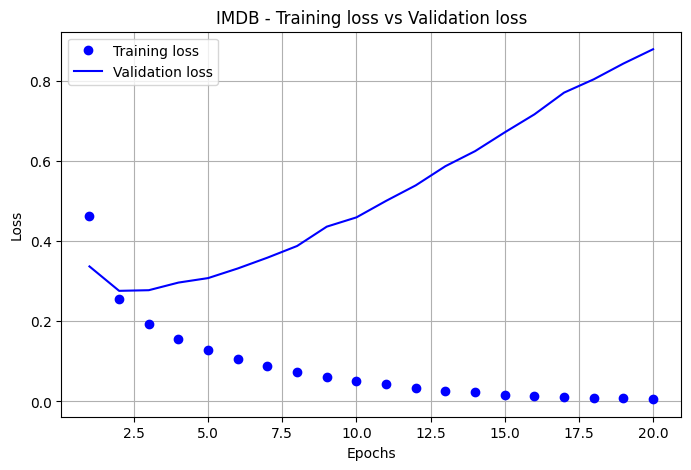

In [6]:
import matplotlib.pyplot as plt

# Take loss values from history
loss_values = history['loss']
val_loss_values = history['val_loss']

# create variables
epochs = range(1, len(loss_values) + 1)

# Plotting Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('IMDB - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Multi-Class Classification**

Multi-class classification extends binary classification to problems with more than two classes. In this type of task, each data point is assigned to exactly one of several possible categories. An example is classifying images of animals into 'cat', 'dog', 'bird', etc.

In [7]:
from tensorflow.keras.datasets import reuters
import numpy as np

# Load the Reuters dataset (keep the 10,000 frequent words just like the IMDB)
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Display the sizes and number of unique labels
print("Train Size:", x_train.shape)
print("Test Size:", x_test.shape)
print("Unique labels:", len(np.unique(y_train)))

# Display the first sample
print("First samples:", len(x_train[0]), "; Label:", y_train[0])

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Size: (8982,)
Test Size: (2246,)
Unique labels: 46
First samples: 87 ; Label: 3


In [8]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

The `to_one_hot` function, which converts integer labels into a one-hot encoded format. For multi-class classification, this is crucial, as each label is represented as a binary vector where only one element is 1 (corresponding to the correct class) and all others are 0.

In [9]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

In [10]:
x_train = vectorize_sequences(x_train, 10000)
x_test = vectorize_sequences(x_test, 10000)

y_train = to_one_hot(y_train, 46)
y_test = to_one_hot(y_test, 46)

print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)
print('Shape y_train:', y_train.shape)
print('Shape y_test :', y_test.shape)

Shape x_train: (8982, 10000)
Shape x_test : (2246, 10000)
Shape y_train: (8982, 46)
Shape y_test : (2246, 46)


In [11]:
# Validation set for the training process
x_val_reuters = x_train[:1000]
partial_x_train_reuters = x_train[1000:]
y_val_reuters = y_train[:1000]
partial_y_train_reuters = y_train[1000:]

print("Shape x_val_reuters:", x_val_reuters.shape)
print("Shape partial_x_train_reuters:", partial_x_train_reuters.shape)
print("Shape y_val_reuters:", y_val_reuters.shape)
print("Shape partial_y_train_reuters:", partial_y_train_reuters.shape)

Shape x_val_reuters: (1000, 10000)
Shape partial_x_train_reuters: (7982, 10000)
Shape y_val_reuters: (1000, 46)
Shape partial_y_train_reuters: (7982, 46)


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

# Training the model
hidden_layer1 = layers.Dense(64, activation='relu')
hidden_layer2 = layers.Dense(64, activation='relu')

# Output Layer needs 46 neurons → 46 probabilities
output_layer = layers.Dense(46, activation='softmax')

reuters_model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])

In [13]:
# Compile
reuters_model.compile(optimizer='rmsprop',
                      loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
# Fit the model
history_reuters = reuters_model.fit(partial_x_train_reuters, partial_y_train_reuters,
                                   epochs=20, batch_size=256,
                                    validation_data=(x_val_reuters, y_val_reuters),
                                   verbose=1)
# Save to history for visualization
history = history_reuters.history

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5520 - loss: 2.2863 - val_accuracy: 0.6800 - val_loss: 1.4687
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7313 - loss: 1.2345 - val_accuracy: 0.7150 - val_loss: 1.1785
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7980 - loss: 0.9179 - val_accuracy: 0.7860 - val_loss: 1.0209
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8462 - loss: 0.6997 - val_accuracy: 0.8010 - val_loss: 0.9420
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8840 - loss: 0.5354 - val_accuracy: 0.8050 - val_loss: 0.9318
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9083 - loss: 0.4170 - val_accuracy: 0.8110 - val_loss: 0.8842
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9246 - loss: 0.3349 - val_accuracy: 0.8010 - val_loss: 0.8782
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9380 - loss: 0.2751 - val_accuracy: 0.8120 - v

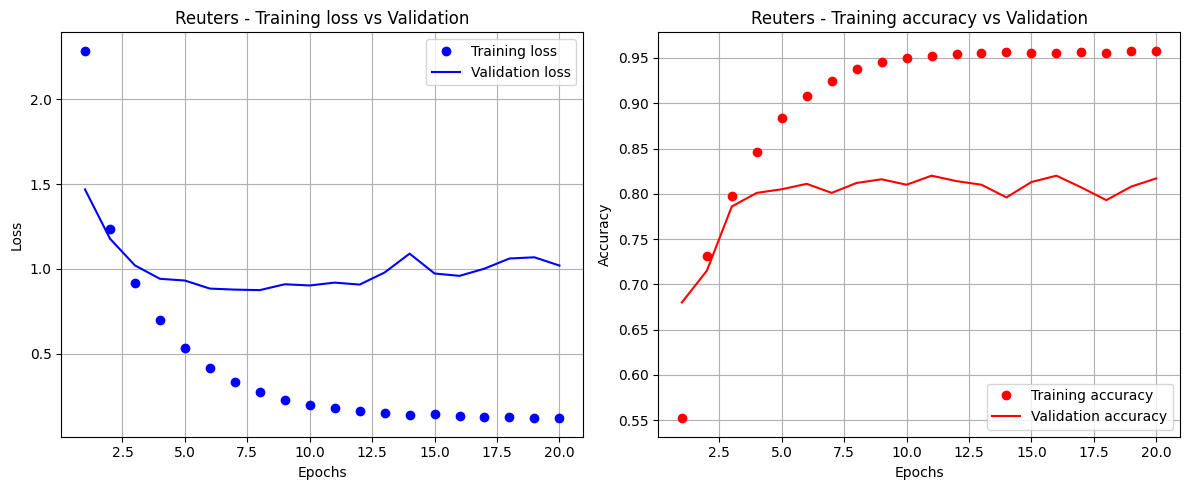

In [15]:
import matplotlib.pyplot as plt

history_dict = history_reuters.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax[0].plot(epochs, loss, 'bo', label='Training loss')
ax[0].plot(epochs, val_loss, 'b', label='Validation loss')
ax[0].set_title('Reuters - Training loss vs Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, acc, 'ro', label='Training accuracy')
ax[1].plot(epochs, val_acc, 'r', label='Validation accuracy')
ax[1].set_title('Reuters - Training accuracy vs Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Predict probabilities for the first test sample
predictions = reuters_model.predict(x_test)

first_prediction = predictions[0]

print("Predicted probabilities:", first_prediction)
print("Sum of probabilities:", np.sum(first_prediction))
print("Predicted label:", np.argmax(first_prediction))
print("Actual label   :", np.argmax(y_test[0]))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predicted probabilities: [5.0955100e-07 3.0484304e-07 2.1749290e-08 9.9691457e-01 2.9303825e-03
 1.8460336e-10 1.3287161e-07 6.7961872e-07 2.8577577e-07 3.0656267e-08
 3.7391779e-09 6.1375576e-06 4.3386641e-09 3.6405174e-05 1.6857638e-07
 1.9813383e-08 3.0147648e-06 4.3455213e-09 5.5133018e-09 2.0594271e-06
 9.3033843e-05 8.8307443e-06 1.1462247e-09 3.1275061e-07 3.4856473e-10
 1.8306542e-07 7.4848932e-13 2.4860072e-09 9.8609760e-08 3.0617483e-07
 4.2857741e-07 1.0708025e-08 5.5975713e-09 5.4044120e-11 9.4499981e-09
 4.5900217e-09 1.4219977e-06 3.4432553e-08 1.7158546e-07 1.7457333e-07
 1.3532127e-09 4.4204742e-09 5.4940944e-08 1.1681982e-10 1.9488399e-11
 5.0790341e-09]
Sum of probabilities: 0.9999999
Predicted label: 3
Actual label   : 3


**Regression**

Regression is a supervised learning technique used to predict a continuous target variable. Unlike classification, which predicts discrete labels, regression models predict numerical values. Common applications include predicting house prices, stock values, or temperature.

In [17]:
from tensorflow.keras.datasets import boston_housing

# Load the boston housing dataset
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

# Display shape
print('Training set shape:', x_train.shape)
print('Testing set shape:', y_train.shape)
print('Train targets shape:', x_test.shape)
print('5 first target  :', y_test[:5])

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (404, 13)
Testing set shape: (404,)
Train targets shape: (102, 13)
5 first target  : [ 7.2 18.8 19.  27.  22.2]


In [18]:
# Find mean and standard deviation
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

# Normalize the data
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# Print the mean and std of the normalized data

print('Mean:', x_train.mean())
print('Std :', x_train.std())

Mean: 2.6016254395785847e-15
Std : 0.9999999999999993


In [21]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model

def build_model():
  hidden_layer1 = layers.Dense(64, activation='relu')
  hidden_layer2 = layers.Dense(64, activation='relu')
  output_layer = layers.Dense(1)

  model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])
  model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
  return model

# Create a model
model = build_model()

In [22]:
# Training the Model (50 Epochs, Batch Size 16)
history = model.fit(x_train, y_train, epochs=50, batch_size=16,
                    validation_split=0.2, verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 489.2444 - mae: 20.1140 - val_loss: 487.4956 - val_mae: 20.0410
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 350.6141 - mae: 16.4153 - val_loss: 320.3704 - val_mae: 15.5778
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 206.0513 - mae: 11.9827 - val_loss: 187.1593 - val_mae: 11.1453
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 107.6127 - mae: 8.0615 - val_loss: 98.8227 - val_mae: 7.3802
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 59.4336 - mae: 5.7139 - val_loss: 58.6477 - val_mae: 5.5308
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40.0437 - mae: 4.5982 - val_loss: 40.3091 - val_mae: 4.6056
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.8752 - mae: 3.8285 - val_loss: 30.2741 - val_mae: 3.9704
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.1195 - mae: 3.3780 - val_loss: 25.4702 - val_mae: 3.5686
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6

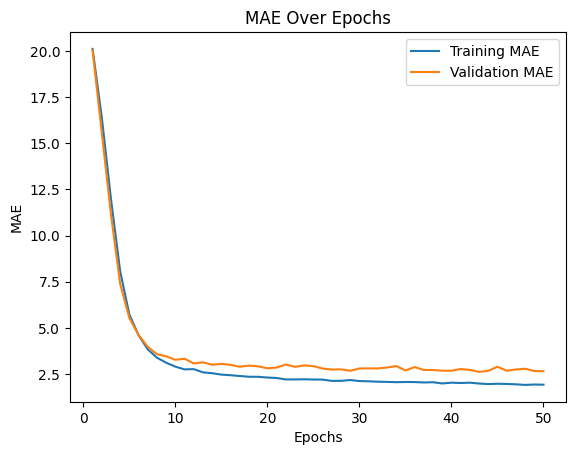

In [23]:
# Extract MAE Across Epochs
import matplotlib.pyplot as plt

mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(mae) + 1)

plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE Over Epochs')
plt.show()

In [24]:
import numpy as np

# Mean MAE Calculation
mean_mae = np.mean(mae)
print("Mean Training MAE:", mean_mae)

Mean Training MAE: 3.338330140113831


In [25]:
# Mean MAE Calculation for validation
mean_val_mae = np.mean(val_mae)
print("Mean Validation MAE:", mean_val_mae)

Mean Validation MAE: 3.8381196451187134
